In [1]:
import pandas as pd

In [2]:
from gensim.models import Word2Vec

In [3]:
from sklearn.metrics import f1_score

In [4]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

torch._inductor.config.triton.cudagraph_skip_dynamic_graphs=True
torch.backends.fp32_precision = "tf32"
torch.backends.cudnn.fp32_precision = "tf32"
torch.backends.cudnn.rnn.fp32_precision = "tf32"

In [5]:
assert torch.cuda.is_available()
device = torch.device("cuda")
print(f"Device: {device}")

Device: cuda


In [6]:
import site
site.addsitedir("./../neuralnetwork")
from nn_lstm_preprocessing import preprocess_element

### LOAD MODEL

In [7]:
embedding_model = Word2Vec.load("../models/embedding_model.model")

In [9]:
class WordRNN(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, tagset_size=1):
        super(WordRNN, self).__init__()

        self.word_embeddings = nn.Embedding.from_pretrained(torch.tensor(embedding_model.wv.vectors))
        self.word_embeddings.weight.requires_grad = False
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, article_data, article_lengths):
        article_embeddings_tensor = self.word_embeddings(article_data)
        
        packed_data = pack_padded_sequence(article_embeddings_tensor, article_lengths, batch_first=True, enforce_sorted=False)
        output, (h_n, c_n) = self.lstm(article_embeddings_tensor)
        last_hidden = h_n[-1]

        logit = self.fc(last_hidden)

        return logit

In [10]:
model = WordRNN(128, 256)

model = model.to("cuda")
model = torch.compile(model, mode="max-autotune-no-cudagraphs")
model

OptimizedModule(
  (_orig_mod): WordRNN(
    (word_embeddings): Embedding(385220, 128)
    (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [12]:
model.load_state_dict(torch.load("../models/nn_model2.pth"))

<All keys matched successfully>

### EVALUATION

In [13]:
data = pd.read_csv("../data/lair_data_cleaned.csv", usecols=["content", "type"])

In [14]:
data["content"] = data["content"].apply(lambda x: preprocess_element(embedding_model, x))

In [15]:
for index, (label, article) in data.iterrows():
    print(torch.tensor(article.shape))
    print(type(article.shape))
    break

tensor([7])
<class 'torch.Size'>


In [16]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for index, (label, article) in data.iterrows():
        article = article.to(device, non_blocking=True)

        output = model(article, torch.tensor(article.shape))
        probability = torch.sigmoid(output)
        prediction = (probability > 0.5).long().cpu()

        predictions.append(prediction)
        true_labels.append(torch.tensor([label]))

In [23]:
evaluation_score = f1_score(torch.cat(true_labels), torch.cat(predictions), pos_label=1)
evaluation_score

0.4380639868744873

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

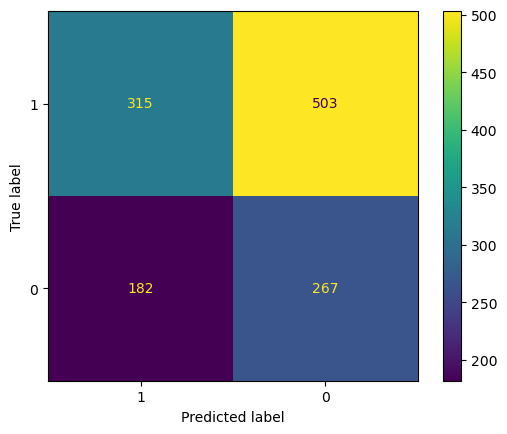

In [19]:
conf_ma = confusion_matrix(torch.cat(true_labels), torch.cat(predictions))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_ma, display_labels=[1,0])
disp.plot()